# Standalone 2D T-P Response Plot for SVGP Residual

Loads the trained SVGP model (`SVGP_RESIDUAL_OUTPUTS/SVGP_residual_model.pt`) and produces only the 2D ⟨Δγ⟩ surface in (T, P) space, clipped to the phase envelope.

**Fixes vs. original**
1. Clip polygon built on the full T-grid via the envelope interpolators → no white gap at low T.
2. `pcolormesh` (Gouraud shading) for a continuous colourbar.
3. Single-hue `Blues_r` colourmap with data-driven asymmetric limits.
4. Phase-envelope curves are *cross-composition maxima* — some training points lie below `max P_dew` because they belong to compositions with lower dew lines (not unphysical).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gpytorch

import thermoift.PLOT_SETTINGS as ps
from matplotlib.ticker import AutoMinorLocator
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy.spatial import Delaunay
from scipy.interpolate import interp1d, CloughTocher2DInterpolator, NearestNDInterpolator
from sklearn.model_selection import train_test_split

OUTPUT_FOLDER = "SVGP_RESIDUAL_OUTPUTS"
MODEL_PATH    = os.path.join(OUTPUT_FOLDER, "SVGP_residual_model.pt")
SEED          = 4555525

print(f"PyTorch  : {torch.__version__}")
print(f"GPyTorch : {gpytorch.__version__}")

PyTorch  : 2.10.0+cpu
GPyTorch : 1.15.2


In [2]:
class SVGPModel(gpytorch.models.ApproximateGP):
    """Same architecture used during training."""

    def __init__(self, inducing_points: torch.Tensor):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution,
            learn_inducing_locations=True)
        super().__init__(variational_strategy)
        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5,
                                          ard_num_dims=inducing_points.shape[1]))

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x))


def predict_batched(model, likelihood, X_tensor, batch_size=2048):
    model.eval(); likelihood.eval()
    means = []
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for i in range(0, len(X_tensor), batch_size):
            xb = X_tensor[i:i + batch_size]
            means.append(likelihood(model(xb)).mean.numpy())
    return np.concatenate(means)


class SVGPWrapper:
    """Predict-only wrapper that mirrors the QT → std → model pipeline."""

    def __init__(self, model, likelihood, scaler, qt, y_mean, y_std):
        self._model = model
        self._likelihood = likelihood
        self._scaler = scaler
        self._qt = qt
        self._y_mean = y_mean
        self._y_std = y_std

    def predict(self, X):
        if not isinstance(X, np.ndarray):
            X = np.asarray(X, dtype=np.float32)
        Xs = self._scaler.transform(X).astype(np.float32)
        Xt = torch.from_numpy(Xs)
        m_norm = predict_batched(self._model, self._likelihood, Xt)
        m_qt   = m_norm * self._y_std + self._y_mean
        return self._qt.inverse_transform(m_qt.reshape(-1, 1)).ravel()

In [3]:
state = torch.load(MODEL_PATH, weights_only=False, map_location="cpu")

scaler   = state["scaler"]
qt       = state["qt"]
y_mean   = state["y_mean"]
y_std    = state["y_std"]
features = state["features"]
target   = state["target"]
n_ind    = state["n_inducing"]

# Reconstruct SVGP with dummy inducing points, then load weights
dummy_ip   = torch.zeros(n_ind, len(features), dtype=torch.float32)
svgp_model = SVGPModel(dummy_ip)
svgp_model.load_state_dict(state["model_state_dict"])

likelihood = gpytorch.likelihoods.GaussianLikelihood()
likelihood.load_state_dict(state["likelihood_state_dict"])

svgp_wrapper = SVGPWrapper(svgp_model, likelihood, scaler, qt, y_mean, y_std)
print(f"Loaded model with {n_ind} inducing points, {len(features)} features.")
print(f"Features: {features}")

Loaded model with 2000 inducing points, 9 features.
Features: ['T', 'P', 'z_argon', 'z_carbon_dioxide', 'z_carbon_monoxide', 'z_hydrogen', 'z_hydrogen_sulfide', 'z_methane', 'z_nitrogen']


In [4]:
# Training-set X for grid bounds & scatter overlay (must match the training split)
df_train_full = pd.read_csv("../CombinedDatasetSEC_A4.csv")
df_train_full.columns = [c.strip().replace(" ", "_") for c in df_train_full.columns]
df_train_full = df_train_full.dropna(
    subset=["gamma_wsd", "gamma_cDFT_minus_wsd_uncorrected", "gamma_wsd_UC"]).copy()
df_train_full["gamma_cDFT_UC"] = (df_train_full["gamma_wsd_UC"]
                                  + df_train_full["gamma_cDFT_minus_wsd_uncorrected"])
df_train_full["residual"] = df_train_full["gamma_cDFT_UC"] - df_train_full["gamma_wsd_UC"]

X = df_train_full[features]
y = df_train_full[target]

# Same 70/15/15 split as the training notebook
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test,  X_val,  y_test,  y_val  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

T_train = X_train["T"].values
P_train = X_train["P"].values

# Phase-envelope dataset
df_env_full = pd.read_csv("../../interfacial_results_dataset_A4.csv")
df_max = (df_env_full.groupby("temperature")[["P_bubble", "P_dew"]]
                       .max().reset_index().sort_values("temperature").dropna())
df_env = df_max.iloc[:-1].copy()
T_env     = df_env["temperature"].values
P_bub_env = df_env["P_bubble"].values
P_dew_env = df_env["P_dew"].values

bub_interp = interp1d(T_env, P_bub_env, kind="linear", bounds_error=False,
                      fill_value=(P_bub_env[0], P_bub_env[-1]))
dew_interp = interp1d(T_env, P_dew_env, kind="linear", bounds_error=False,
                      fill_value=(P_dew_env[0], P_dew_env[-1]))

print(f"X_train: {X_train.shape}")
print(f"Envelope T-range: [{T_env.min():.1f}, {T_env.max():.1f}] K")

X_train: (16130, 9)
Envelope T-range: [200.0, 295.0] K


In [5]:
# Coarse prediction grid
n_grid = 120
T_vals = np.linspace(T_train.min(), T_train.max(), n_grid)
P_vals = np.linspace(P_train.min(), P_train.max(), n_grid)
TT, PP = np.meshgrid(T_vals, P_vals)

hull    = Delaunay(np.column_stack([T_train, P_train]))
in_hull = hull.find_simplex(np.column_stack([TT.ravel(), PP.ravel()])) >= 0
in_env  = (PP.ravel() <= bub_interp(TT.ravel())) & (PP.ravel() >= dew_interp(TT.ravel()))
mask    = (in_hull & in_env).reshape(n_grid, n_grid)

T_idx, P_idx = features.index("T"), features.index("P")
X_ref = X_train.median().values.copy()
X_grid = np.tile(X_ref, (n_grid * n_grid, 1))
X_grid[:, T_idx] = TT.ravel()
X_grid[:, P_idx] = PP.ravel()

mean_flat = svgp_wrapper.predict(pd.DataFrame(X_grid, columns=features))
mean_grid = mean_flat.reshape(n_grid, n_grid).astype(float)
mean_grid[~mask] = np.nan

# Dense smooth field — keep TWO versions
valid_pts  = np.column_stack([TT[~np.isnan(mean_grid)], PP[~np.isnan(mean_grid)]])
valid_vals = mean_grid[~np.isnan(mean_grid)]
ct_interp  = CloughTocher2DInterpolator(valid_pts, valid_vals)
nn_fill    = NearestNDInterpolator(valid_pts, valid_vals)

n_smooth = 500
T_vals_s = np.linspace(T_train.min(), T_train.max(), n_smooth)
P_vals_s = np.linspace(P_train.min(), P_train.max(), n_smooth)
TT_s, PP_s = np.meshgrid(T_vals_s, P_vals_s)

in_hull_s = hull.find_simplex(np.column_stack([TT_s.ravel(), PP_s.ravel()])) >= 0
in_env_s  = (PP_s.ravel() <= bub_interp(TT_s.ravel())) & (PP_s.ravel() >= dew_interp(TT_s.ravel()))
mask_s    = (in_hull_s & in_env_s).reshape(n_smooth, n_smooth)

# (a) Fully-filled field for pcolormesh — every cell is defined, no NaNs.
#     This avoids Gouraud-shading artefacts at the envelope edge.
Z_full = ct_interp(TT_s, PP_s)
nan_holes = np.isnan(Z_full)
Z_full[nan_holes] = nn_fill(TT_s[nan_holes], PP_s[nan_holes])

# (b) Masked copy for the isolines — lines must stop at the envelope.
Z_for_contour = np.where(mask_s, Z_full, np.nan)
Z_for_contour = np.ma.masked_invalid(Z_for_contour)

# Colour limits taken from the in-envelope region only
vmin = float(np.nanpercentile(Z_full[mask_s],  1.0))
vmax = float(np.nanpercentile(Z_full[mask_s], 99.0))
line_levels = np.linspace(vmin, vmax, 9)
print(f"Colour limits: vmin={vmin:.3f}  vmax={vmax:.3f}")

/home/darshan/A6/py_A6/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Colour limits: vmin=-4.606  vmax=-0.097


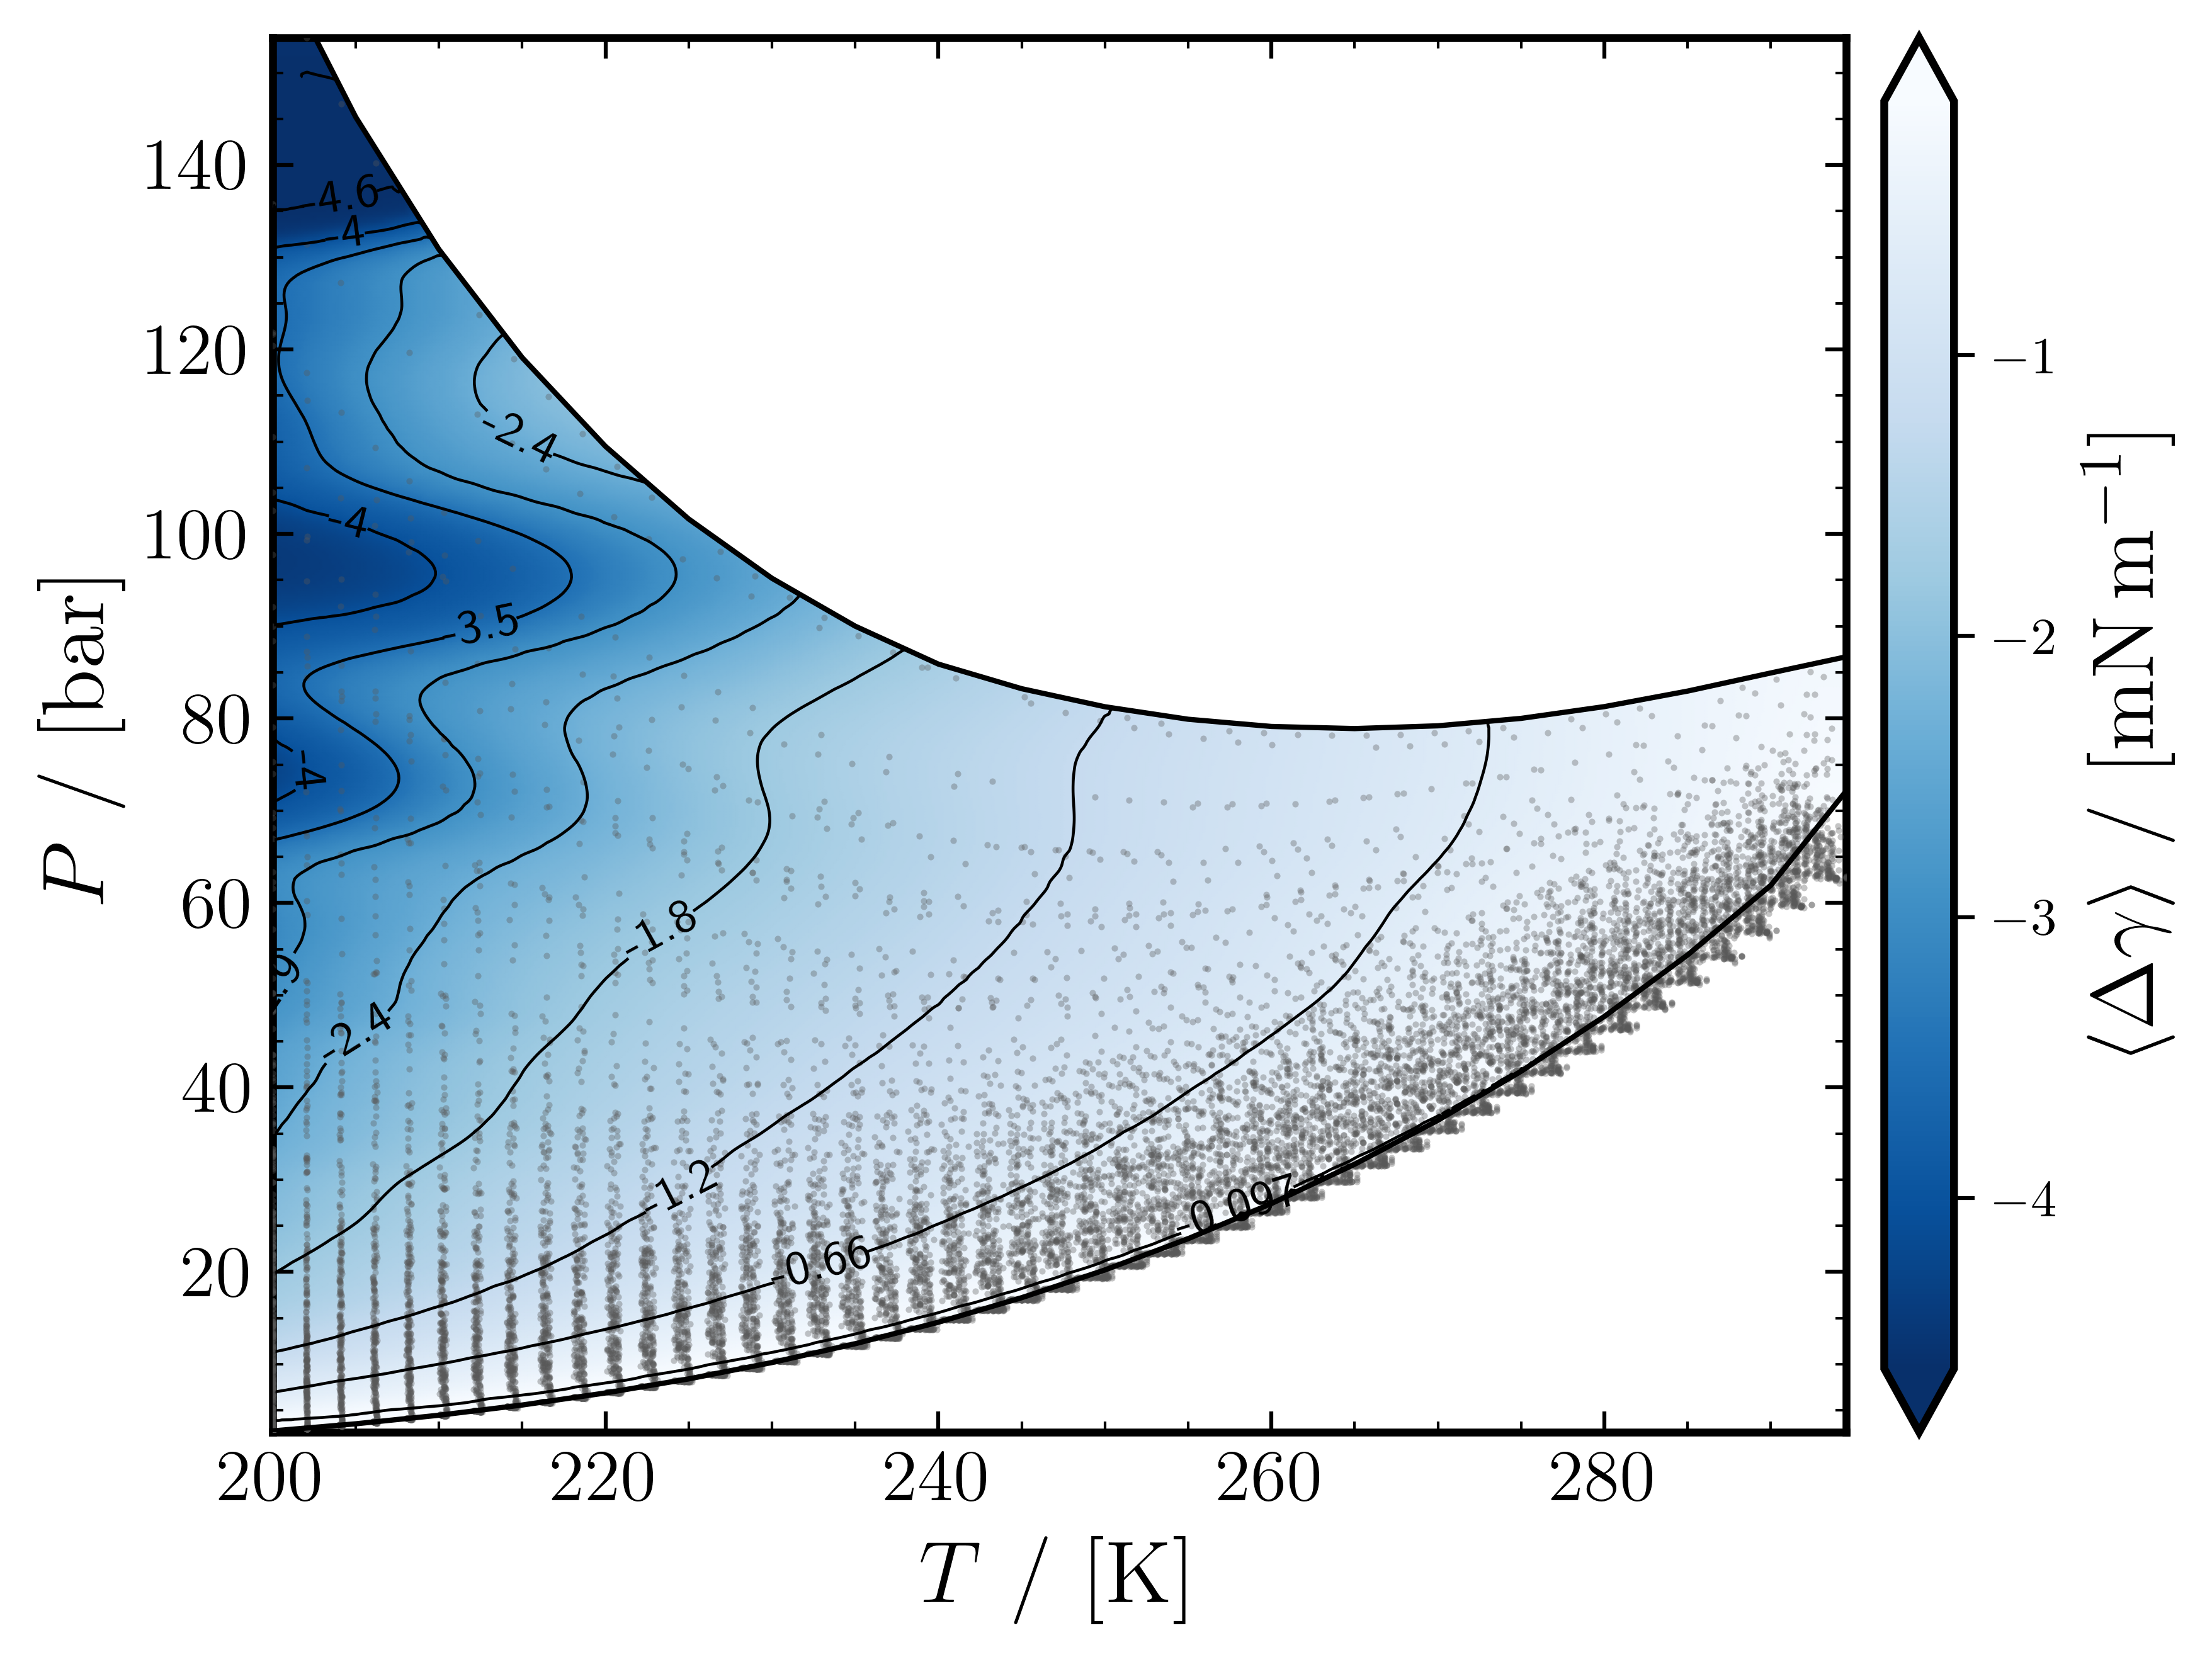

In [6]:
# Envelope clip polygon — built on the full T-grid via the interpolators
clip_T_seq = T_vals_s
clip_P_top = bub_interp(clip_T_seq)
clip_P_bot = dew_interp(clip_T_seq)
clip_T = np.concatenate([clip_T_seq, clip_T_seq[::-1]])
clip_P = np.concatenate([clip_P_top, clip_P_bot[::-1]])
clip_path = Path(np.column_stack([clip_T, clip_P]), closed=True)

def _apply_clip(artist, patch):
    try:
        artist.set_clip_path(patch)
    except AttributeError:
        for coll in getattr(artist, "collections", []):
            coll.set_clip_path(patch)

fig, ax = ps.plot_init(w=6, h=4.5)
clip_patch = PathPatch(clip_path, facecolor="none", edgecolor="none", transform=ax.transData)
ax.add_patch(clip_patch)

# Surface: use the fully-defined field, no NaNs → no Gouraud edge artefacts
pcm = ax.pcolormesh(TT_s, PP_s, Z_full,
                    cmap="Blues_r", vmin=vmin, vmax=vmax,
                    shading="gouraud", zorder=1)
_apply_clip(pcm, clip_patch)

# Training-data markers
ax.scatter(T_train, P_train, color="0.35", s=1.5, alpha=0.35,
           linewidths=0, zorder=3)

# Isolines: use the masked copy so lines terminate at the envelope
cs = ax.contour(TT_s, PP_s, Z_for_contour, levels=line_levels,
                colors="black", linewidths=0.55, linestyles="solid",
                corner_mask=True, zorder=6)
_apply_clip(cs, clip_patch)
ax.clabel(cs, inline=True, inline_spacing=3,
          fontsize=ps.label_fontsize * 0.65, fmt="%.2g")

ax.plot(T_env, P_bub_env, "-", color='k',
        linewidth=ps.linewidth, markersize=ps.markersize, zorder=7)
ax.plot(T_env, P_dew_env, "-", color='k',
        linewidth=ps.linewidth, markersize=ps.markersize, zorder=7)

cbar = fig.colorbar(pcm, ax=ax, pad=0.02, extend="both")
cbar.set_label(
    r"$\langle\Delta\gamma\rangle\ /\ [\mathrm{mN}\,\mathrm{m}^{-1}]$",
    fontsize=ps.label_fontsize*1.2)
cbar.ax.tick_params(labelsize=ps.label_fontsize*1.5)
ps.style_colorbar(cbar)

ax.set_xlabel(r"$T\ /\ [\mathrm{K}]$", fontsize=ps.label_fontsize*1.2)
ax.set_ylabel(r"$P\ /\ [\mathrm{bar}]$", fontsize=ps.label_fontsize*1.2)
ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=ps.label_fontsize)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(T_train.min(), T_train.max())
ax.set_ylim(P_train.min(), P_train.max())
# ps.style_legend(ax, loc="upper right")

plt.tight_layout()
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
ps.save_plot(fig, "SVGP_2D_response_T_P_standalone", folder=OUTPUT_FOLDER)
plt.show()